In [9]:
# 1. Data Manipulation & Time-Series
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 2. Financial Data
import yfinance as yf

# 3. NLP & Deep Learning (HuggingFace & PyTorch)
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline

# 4. Machine Learning & Ensembling
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report

# 5. Financial Cross-Validation (CRITICAL)
from sklearn.model_selection import TimeSeriesSplit

In [8]:
pip install transformers


  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.9.0-py3-none-any.whl.metadata (14 kB)
  Using cached regex-2026.4.4-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
Using cached huggingface_hub-1.9.0-py3-none-any.whl (637 kB)
Using cached regex-2026.4.4-cp312-cp312-win_amd64.whl (277 kB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl (3.7 MB)
  Attempting uninstall: regex
    Found existing installation: regex 2024.9.11
    Uninstalling regex-2024.9.11:
      Successfully uninstalled regex-2024.9.11
Note: you may need to restart the kern

In [1]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("financial_news_events.csv")

# 2. Drop rows where we don't have a Headline or Index_Change_Percent
df_clean = df.dropna(subset=['Headline', 'Index_Change_Percent']).copy()

# 3. Filter ONLY for the Indian Market (NSE Nifty)
df_india = df_clean[df_clean['Market_Index'] == 'NSE Nifty'].copy()

# 4. Convert 'Date' to a proper Datetime object
df_india['Date'] = pd.to_datetime(df_india['Date'])

# 5. Create our Target Variable (1 if the market went UP, 0 if DOWN)
df_india['Target_Direction'] = (df_india['Index_Change_Percent'] > 0).astype(int)

# Sort by date to maintain chronological order
df_india = df_india.sort_values('Date').reset_index(drop=True)

print(f"Cleaned Indian Market dataset size: {df_india.shape}")
display(df_india[['Date', 'Headline', 'Index_Change_Percent', 'Target_Direction']].head())

Cleaned Indian Market dataset size: (144, 13)


,Date,Headline,Index_Change_Percent,Target_Direction
0,2025-02-01,Consumer confidence index reaches a decade high,0.35,1
1,2025-02-05,Unexpected rise in unemployment fuels market p...,3.16,1
2,2025-02-06,Consumer confidence index reaches a decade high,3.18,1
3,2025-02-09,Massive stock buyback program announced by a c...,-4.03,0
4,2025-02-09,Government subsidy program gives a lift to the...,1.30,1


In [3]:
pip install torch 

  Using cached torch-2.11.0-cp312-cp312-win_amd64.whl.metadata (29 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
Using cached torch-2.11.0-cp312-cp312-win_amd64.whl (114.6 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.2
    Uninstalling sympy-1.13.2:
      Successfully uninstalled sympy-1.13.2
Note: you may need to restart the kernel to use updated packages.


In [10]:
import torch
from transformers import pipeline

# 1. Initialize the FinBERT pipeline
print("Downloading FinBERT model... (This might take a minute)")
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", tokenizer="ProsusAI/finbert")

# 2. Define a function to score text safely
def get_finbert_score(text):
    try:
        # Get prediction
        result = finbert(text)[0] 
        label = result['label']
        
        # Map textual labels to numeric scores
        if label == 'positive': return 1.0
        elif label == 'negative': return -1.0
        else: return 0.0 # neutral
    except:
        return 0.0 # fallback for any weird text formats

# 3. Apply the model to our headlines
print("Analyzing sentiment of Indian financial news...")
df_india['FinBERT_Score'] = df_india['Headline'].apply(get_finbert_score)

print("Sentiment Analysis Complete!")
display(df_india[['Headline', 'FinBERT_Score', 'Target_Direction']].head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyzing sentiment of Indian financial news...
Sentiment Analysis Complete!


,Headline,FinBERT_Score,Target_Direction
0,Consumer confidence index reaches a decade high,1.0,1
1,Unexpected rise in unemployment fuels market p...,-1.0,1
2,Consumer confidence index reaches a decade high,1.0,1
3,Massive stock buyback program announced by a c...,0.0,0
4,Government subsidy program gives a lift to the...,1.0,1


In [11]:
# Fetch NIFTY Bank data (1-hour intervals for the last 730 days)
ticker = "^NSEBANK" 
market_data = yf.download(ticker, interval="1h", period="730d")
market_data.reset_index(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [12]:
import torch
from transformers import pipeline

# 1. Initialize the FinBERT pipeline
print("Downloading FinBERT model... (This might take a minute)")
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", tokenizer="ProsusAI/finbert")

# 2. Define a function to score text safely
def get_finbert_score(text):
    try:
        # Get prediction
        result = finbert(text)[0] 
        label = result['label']
        
        # Map textual labels to numeric scores
        if label == 'positive': return 1.0
        elif label == 'negative': return -1.0
        else: return 0.0 # neutral
    except:
        return 0.0 # fallback for any weird text formats

# 3. Apply the model to our headlines
print("Analyzing sentiment of Indian financial news...")
df_india['FinBERT_Score'] = df_india['Headline'].apply(get_finbert_score)

print("Sentiment Analysis Complete!")
display(df_india[['Headline', 'FinBERT_Score', 'Target_Direction']].head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyzing sentiment of Indian financial news...
Sentiment Analysis Complete!


,Headline,FinBERT_Score,Target_Direction
0,Consumer confidence index reaches a decade high,1.0,1
1,Unexpected rise in unemployment fuels market p...,-1.0,1
2,Consumer confidence index reaches a decade high,1.0,1
3,Massive stock buyback program announced by a c...,0.0,0
4,Government subsidy program gives a lift to the...,1.0,1


In [13]:
# 1. Map Ordinal Feature: Impact_Level
impact_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df_india['Impact_Numeric'] = df_india['Impact_Level'].map(impact_mapping)

# 2. One-Hot Encode Nominal Features: Sector and Market_Event
# This turns categories into binary columns (0 or 1)
df_features = pd.get_dummies(df_india, columns=['Sector', 'Market_Event'], drop_first=True)

# 3. Define our final Feature Matrix (X) and Target Vector (y)
# We drop text columns, dates, and the target variable to isolate the features
features_to_drop = ['Date', 'Headline', 'Source', 'Market_Index', 'Index_Change_Percent', 
                    'Sentiment', 'Impact_Level', 'Related_Company', 'News_Url', 'Target_Direction']

X = df_features.drop(columns=features_to_drop)
y = df_features['Target_Direction']

print(f"Feature Matrix Shape: {X.shape}")
display(X.head())

Feature Matrix Shape: (144, 39)


,Trading_Volume,FinBERT_Score,Impact_Numeric,Sector_Agriculture,Sector_Automotive,Sector_Construction,Sector_Consumer Goods,Sector_Energy,Sector_Finance,Sector_Healthcare,...,Market_Event_IPO Launch,Market_Event_Inflation Data Release,Market_Event_Interest Rate Change,Market_Event_Major Merger/Acquisition,Market_Event_Market Rally,Market_Event_Regulatory Changes,Market_Event_Stock Market Crash,Market_Event_Supply Chain Disruption,Market_Event_Trade Tariffs Announcement,Market_Event_Unemployment Rate Announcement
0,113.41,1.0,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,460.81,-1.0,3,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,210.88,1.0,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,266.37,0.0,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,433.21,1.0,2,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [14]:
# Calculate the split index (80% for training, 20% for testing)
split_idx = int(len(X) * 0.8)

# Split the data chronologically
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training Data: {len(X_train)} days")
print(f"Testing Data: {len(X_test)} days")

Training Data: 115 days
Testing Data: 29 days


In [15]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the XGBoost Classifier
# We use logloss for binary classification and add some regularization to prevent overfitting
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

# 2. Train the model
print("Training XGBoost Model...")
xgb_model.fit(X_train, y_train)
print("Training Complete!")

# 3. Make predictions on the unseen future data (X_test)
y_pred = xgb_model.predict(X_test)

# 4. Evaluate Performance
print("\n--- MODEL PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

Training XGBoost Model...
Training Complete!

--- MODEL PERFORMANCE ---
Accuracy: 65.52%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.69      0.69      0.69        16
      Up (1)       0.62      0.62      0.62        13

    accuracy                           0.66        29
   macro avg       0.65      0.65      0.65        29
weighted avg       0.66      0.66      0.66        29



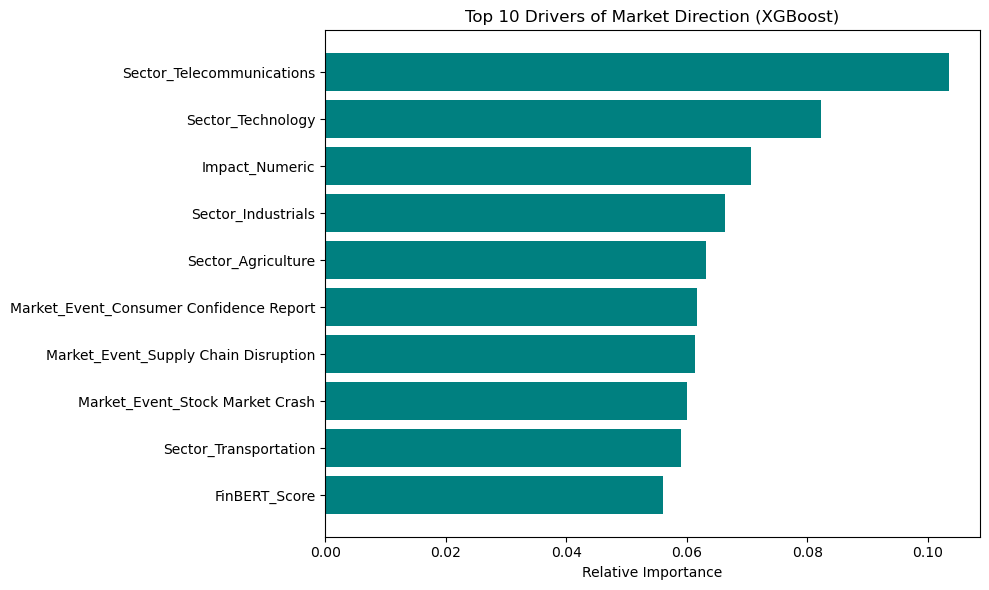

In [16]:
import matplotlib.pyplot as plt

# Get feature importances from the trained model
importances = xgb_model.feature_importances_

# Create a DataFrame for easy plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot the Top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].tail(10), importance_df['Importance'].tail(10), color='teal')
plt.title('Top 10 Drivers of Market Direction (XGBoost)')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Re-attach the actual market returns to our test set
# We kept the original dataset (df_india) which has the exact Index_Change_Percent
test_dates = df_india['Date'].iloc[split_idx:]
actual_returns = df_india['Index_Change_Percent'].iloc[split_idx:] / 100  # Convert to decimal

# 2. Create a DataFrame to hold our backtest results
backtest_df = pd.DataFrame({
    'Date': test_dates,
    'Market_Return': actual_returns,
    'Model_Signal': y_pred
})

# 3. Calculate Strategy Returns
# If Signal is 1 (Buy), we get the Market_Return. If Signal is 0 (Sit in Cash), we get 0.
backtest_df['Strategy_Return'] = backtest_df['Market_Return'] * backtest_df['Model_Signal']

# 4. Calculate Cumulative Returns (How $1 grows over time)
# We use cumulative product: cumulative_return = (1 + r1) * (1 + r2) * ...
backtest_df['Cumulative_Market'] = (1 + backtest_df['Market_Return']).cumprod()
backtest_df['Cumulative_Strategy'] = (1 + backtest_df['Strategy_Return']).cumprod()

print("Backtest calculations complete!")
display(backtest_df.tail())

Backtest calculations complete!


,Date,Market_Return,Model_Signal,Strategy_Return,Cumulative_Market,Cumulative_Strategy
139,2025-08-06,-0.0116,0,-0.000,0.975933,1.097781
140,2025-08-10,-0.0314,0,-0.000,0.945289,1.097781
141,2025-08-12,0.0460,1,0.046,0.988772,1.148279
142,2025-08-12,0.0218,0,0.000,1.010327,1.148279
143,2025-08-12,-0.0040,0,-0.000,1.006286,1.148279


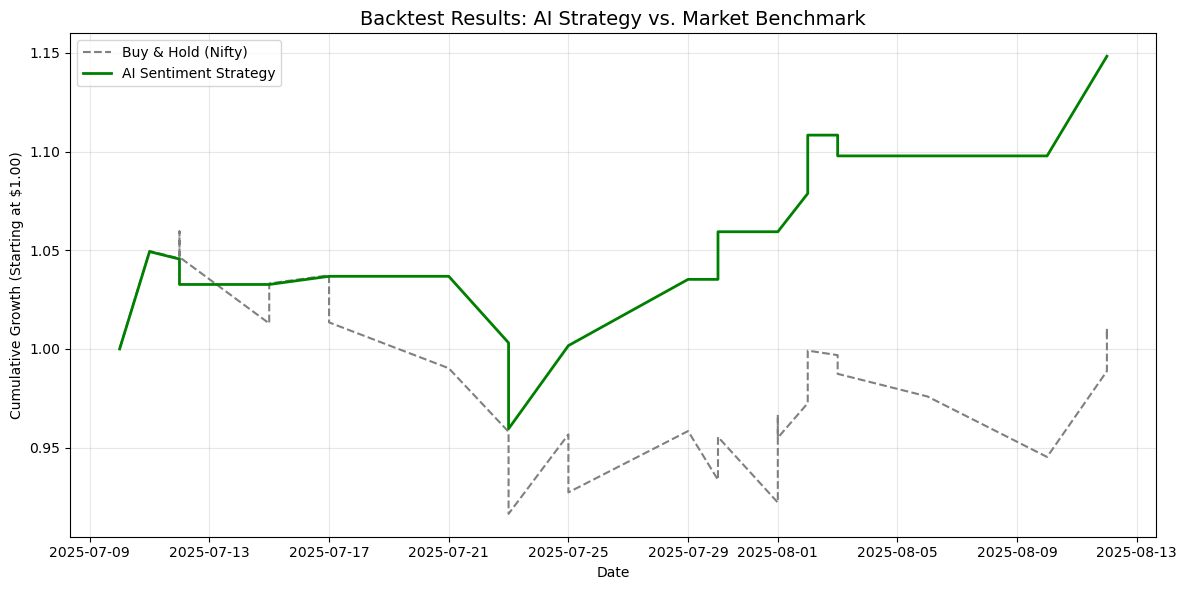

Total Market Return (Buy & Hold): 0.63%
Total AI Strategy Return: 14.83%


In [18]:
# Plotting the Equity Curves
plt.figure(figsize=(12, 6))

plt.plot(backtest_df['Date'], backtest_df['Cumulative_Market'], label='Buy & Hold (Nifty)', color='gray', linestyle='--')
plt.plot(backtest_df['Date'], backtest_df['Cumulative_Strategy'], label='AI Sentiment Strategy', color='green', linewidth=2)

plt.title('Backtest Results: AI Strategy vs. Market Benchmark', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Growth (Starting at $1.00)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate Final Metrics
total_market_return = (backtest_df['Cumulative_Market'].iloc[-1] - 1) * 100
total_strategy_return = (backtest_df['Cumulative_Strategy'].iloc[-1] - 1) * 100

print(f"Total Market Return (Buy & Hold): {total_market_return:.2f}%")
print(f"Total AI Strategy Return: {total_strategy_return:.2f}%")

In [19]:
import joblib

# Save the trained XGBoost model to a file
joblib.dump(xgb_model, 'xgboost_sentiment_model.pkl')

print("Model successfully saved as 'xgboost_sentiment_model.pkl'")


Model successfully saved as 'xgboost_sentiment_model.pkl'
